# DataView: Exploração e Análise de Dados de Vendas

Este notebook apresenta o miniprojeto **DataView: Exploração e Análise de Dados de Vendas**, desenvolvido como parte do Módulo 1 - Semana 08 do curso de Desenvolvedor(a) em IA para Análise Preditiva.

### Objetivos do Projeto:
- Praticar a estruturação e organização de um pipeline de dados em Python.
- Realizar carga, inspeção e limpeza de dados (tratamento de nulos, erros de digitação e inconsistências de data).
- Detectar e tratar outliers usando limites estatísticos (IQR).
- Engenharia de recursos (criação de colunas derivadas de datas e valores).
- Agrupamento e agregação de dados com Pandas `groupby`.
- Segmentação simples de clientes usando lógica condicional.
- Cálculos estatísticos vetorizados com NumPy.
- Visualização de dados usando Matplotlib e Seaborn.
- Leitura e exportação de resultados em CSV e JSON.
- Consolidação do pipeline estruturado em funções reutilizáveis.

In [1]:
# Passo 1: Bloco de importação de bibliotecas
import pandas as pd
import numpy as np
import random
import os
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Ajustar o diretório de trabalho se o notebook estiver sendo executado dentro da pasta 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("Diretório de trabalho ajustado para:", os.getcwd())

print("Bibliotecas importadas com sucesso!")

Diretório de trabalho ajustado para: C:\Users\lgert\OneDrive\Home\Documentos\Curso Sesi Senai\files
Bibliotecas importadas com sucesso!


## RF01 – Criar ou Carregar o Dataset de Vendas

Nesta etapa, geramos sinteticamente um conjunto de dados de vendas de 150 registros contendo algumas inconsistências propositais (valores nulos, textos com espaços extras, datas inválidas) para testar o nosso pipeline de limpeza. O arquivo bruto é salvo em `data/raw/vendas.csv`.

In [2]:
def gerar_dataset_vendas(n_registros=150, seed=42):
    """
    Gera um dataset sintético de vendas com dados propositalmente sujos,
    incluindo valores nulos, strings sujas, datas inválidas e outliers.
    """
    random.seed(seed)
    np.random.seed(seed)
 
    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
    precos = { 'Notebook': 3500, 'Smartphone': 2200, 'Tablet': 1800, 'Monitor': 1200, 'Teclado': 250, 'Mouse': 120 }  
    categorias = { "Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares", "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos" }
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]
 
    data_inicio = datetime(2024, 1, 1)
    dados = []
 
    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)  
        preco = precos[produto]
        data = data_inicio + timedelta(days=random.randint(0, 364)) 
 
        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo 
        if random.random() < 0.04:
            preco = None               # valor nulo 
        if random.random() < 0.03:
            produto = "  " + produto   # espaço extra (string suja) 
 
        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"
 
        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })
 
    return pd.DataFrame(dados)

# Gerar e salvar o dataset bruto
df_bruto = gerar_dataset_vendas()
os.makedirs('data/raw', exist_ok=True)
df_bruto.to_csv("data/raw/vendas.csv", index=False)
print(f"Dataset bruto gerado com {len(df_bruto)} registros.")
df_bruto.head()

Dataset bruto gerado com 150 registros.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0


## RF02 – Inspecionar e Descrever os Dados

Criamos a função `inspecionar_dados` para realizar uma análise descritiva inicial do DataFrame bruto. Ela exibe dimensões, tipos de dados, contagem de nulos, primeiras linhas e estatísticas descritivas básicas.

In [3]:
def inspecionar_dados(df):
    """
    Exibe informações básicas do DataFrame.
    """
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f"\nEstatísticas descritivas:\n{df.describe(include='all')}")
    return df.describe(include="all")

inspecionar_dados(df_bruto)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mous

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


## RF03 – Limpar e Tratar os Dados

Implementamos funções para tratar inconsistências de string usando expressões regulares (módulo `re`), remover nulos em colunas críticas (quantidade, preço), validar datas e convertê-las para datetime, e ajustar tipos numéricos.
A versão intermediária dos dados, contendo a limpeza geral mas mantendo possíveis outliers, é salva como `vendas_v1.csv` em `data/processed/v1_com_outliers/`.

In [4]:
def limpar_strings_regex(df, colunas):  
    """ 
    Usa expressões regulares para normalizar colunas de texto:
    - Colapsa múltiplos espaços internos em um único espaço (re.sub)
    - Remove espaços nas pontas da string (.strip())
    - Preserva células nulas sem lançar erro (pd.notna)
    """  
    df = df.copy() # Não modifica o DataFrame original  
    for col in colunas:  
        df[col] = df[col].apply(  
            # pd.notna(s): verifica se o valor NÃO é nulo antes de processar  
            # re.sub(r"\s+", " ", str(s)): substitui sequências de espaços por um único espaço  
            # .strip(): remove espaços residuais nas pontas  
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s
        )  
    return df  

def limpar_dados(df):  
    """
    Limpa o DataFrame de vendas em quatro etapas:
    1. Normaliza strings com regex (espaços extras)
    2. Converte datas e remove registros com datas inválidas
    3. Remove linhas com valores nulos em colunas obrigatórias
    4. Garante os tipos numéricos corretos
    Retorna: (df_limpo, relatorio) — o relatório documenta o impacto de cada etapa.
    """  
    df = df.copy()  
    n_inicial = len(df)  
    relatorio = {}  
    
    # --- Etapa 1: limpeza de strings com regex ---  
    colunas_texto = df.select_dtypes(include="object").columns  
    df = limpar_strings_regex(df, colunas_texto)  
    
    # --- Etapa 2: conversão de datas ---  
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")  
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())  
    df = df.dropna(subset=["data_venda"])  
    
    # --- Etapa 3: remoção de nulos em colunas obrigatórias ---  
    n_antes = len(df)  
    df = df.dropna(subset=["quantidade", "preco_unitario"]) 
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)  
    
    # --- Etapa 4: garantia de tipos numéricos ---
    df["quantidade"] = df["quantidade"].astype(int)  
    df["preco_unitario"] = df["preco_unitario"].astype(float)  
    
    # --- Relatório final ---  
    relatorio["registros_iniciais"] = n_inicial 
    relatorio["registros_finais"] = len(df) 
    relatorio["registros_removidos_total"] = n_inicial - len(df)
    
    print("=== RELATORIO DE LIMPEZA ===")  
    for k, v in relatorio.items():  
        print(f"  {k}: {v}")  
    return df, relatorio  

# Execução da limpeza geral e geração de v1 (com outliers)
df_v1, relatorio_limpeza = limpar_dados(df_bruto)
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)
df_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)
print(f"\nv1 salva com sucesso em data/processed/v1_com_outliers/vendas_v1.csv")
df_v1.head()

=== RELATORIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 6
  registros_iniciais: 150
  registros_finais: 140
  registros_removidos_total: 10

v1 salva com sucesso em data/processed/v1_com_outliers/vendas_v1.csv


C:\Users\lgert\AppData\Local\Temp\ipykernel_13184\3470205483.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0


## RF04 – Detectar e Tratar Outliers (versões v1 e v2)

Implementamos a função `tratar_outliers` utilizando o método do Intervalo Interquartil (IQR).
Detectamos e removemos outliers nas colunas de `quantidade` e em uma cópia temporária de `receita_total` (para capturar transações com valores discrepantes resultantes do produto de quantidade por preço unitário). A base resultante livre de outliers é salva como `vendas_v2.csv` em `data/processed/v2_outliers_tratado/`.

In [5]:
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """
    Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).
    Parâmetros:
      colunas : lista de colunas numéricas a verificar
      fator (padrão=1.5) : multiplicador do IQR para definir os limites
      metodo : 'remover' exclui as linhas com outliers; 'limitar' aplica winsorização
    """
    df = df.copy()
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr
        
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f'  {col}: {n_out} outliers detectados (lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})')
        
        if metodo == 'remover':
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
    return df

# Cópia temporária para calcular receita_total sem alterar df_v1
df_v1_tmp = df_v1.copy()
df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

# Detectar e tratar outliers
print("=== TRATAMENTO DE OUTLIERS ===")
df_v2 = tratar_outliers(df_v1_tmp, colunas=["quantidade", "receita_total"], metodo='remover')

# Remover coluna temporária para recriar de forma definitiva no RF05
df_v2 = df_v2.drop(columns=["receita_total"])

# Salvar v2
os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)
df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")
print("\nv2 salva com sucesso em data/processed/v2_outliers_tratado/vendas_v2.csv")

=== TRATAMENTO DE OUTLIERS ===
  quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
  receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)

v1 = 140 linhas (com outliers)
v2 = 134 linhas (outliers removidos)
Diferença = 6 linhas removidas

v2 salva com sucesso em data/processed/v2_outliers_tratado/vendas_v2.csv


## RF05 – Criar Colunas Derivadas com Transformações

A partir dos dados sem outliers (`df_v2`), criamos as colunas calculadas:
- `receita_total` (quantidade × preco_unitario)
- Componentes de data: `mes` (inteiro), `trimestre` (Q1, Q2, Q3, Q4) e `ano`.
- `faixa_receita_item` usando a função vetorizada `np.select` para categorizar o valor de cada venda.

In [6]:
def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
    - receita_total: quantidade × preco_unitario
    - mes, trimestre, ano: extraídos de data_venda
    - faixa_receita_item: classificação do valor de cada venda
    """
    df = df.copy()
    
    # Receita total da venda
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]
    
    # Extração de componentes de tempo
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year
    
    # Classificação em faixas de receita por item usando np.select
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")
    
    print("COLUNAS DERIVADAS CRIADAS COM SUCESSO")
    return df

# Criar colunas no dataframe principal (df_v2)
df = criar_colunas_derivadas(df_v2)
df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head()

COLUNAS DERIVADAS CRIADAS COM SUCESSO


,data_venda,receita_total,mes,trimestre,faixa_receita_item
0,2024-01-13,240.0,1,Q1,Baixo Valor
3,2024-06-23,840.0,6,Q2,Médio Valor
4,2024-11-05,10800.0,11,Q4,Alto Valor
6,2024-05-28,14000.0,5,Q2,Alto Valor
7,2024-06-30,13200.0,6,Q2,Alto Valor


## RF06 – Calcular Métricas Agregadas (groupby)

Utilizamos a agregação `groupby` do Pandas para resumir as vendas em quatro dimensões principais:
1. Receita total e volume de itens por mês.
2. Ranking de Top 5 produtos que mais geram receita.
3. Receita consolidada por categoria.
4. Desempenho de receita e ticket médio de venda por região geográfica.

In [7]:
def calcular_metricas(df):
    """
    Calcula e retorna um dicionário com métricas agregadas por
    quatro dimensões: mês, produto, categoria e região.
    """
    metricas = {}
    
    # --- Receita e volume por mês ---
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),
              quantidade=("quantidade", "sum"),
              n_vendas=("id_venda", "count")
          )
          .reset_index()
          .sort_values("mes")
    )
    
    # --- Top 5 produtos por receita total ---
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )
    
    # --- Receita por categoria ---
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )
    
    # --- Receita e ticket médio por região ---
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean")
          )
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )
    
    # Exibir no console/notebook
    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))
        
    return metricas

metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1        55690.0          52        10
   2        60840.0          60        12
   3        49050.0          62        11
   4       143040.0          73        13
   5        99390.0          85        15
   6        81940.0          50         8
   7        79780.0          64        13
   8        66280.0          50        12
   9        30280.0          39         8
  10        89450.0          49        11
  11       114950.0          74        13
  12        57760.0          49         8

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet       261000.0
Smartphone       257400.0
  Notebook       227500.0
   Monitor       134400.0
   Teclado        30750.0

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares       518400.0
Computadores       361900.0
 Periféricos        48150.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
       Norte       289120.0   7814.054054
     Sudeste       2

## RF07 – Segmentar Clientes por Nível de Gasto

Classificamos nossos clientes agregando o gasto total de cada um deles e categorizando-os em três níveis (Ouro, Prata, Bronze) através do método `.apply` combinado com uma função **lambda** contendo ternários aninhados.

In [8]:
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto por cada um
    e classifica em Bronze / Prata / Ouro conforme os limites:
    - < R$ 5.000          → Bronze
    - R$ 5.000–R$ 15.000  → Prata
    - > R$ 15.000         → Ouro
    """
    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )
    clientes_df.columns = ["cliente", "total_gasto"]
    
    # Lambda com ternário aninhado
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )
    
    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)
    
    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")
    
    return clientes_df

clientes = segmentar_clientes(df)

=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
    cliente  total_gasto segmento
Cliente_018      67840.0     Ouro
Cliente_014      67160.0     Ouro
Cliente_004      61800.0     Ouro
Cliente_029      52330.0     Ouro
Cliente_024      51940.0     Ouro
Cliente_019      48010.0     Ouro
Cliente_008      47940.0     Ouro
Cliente_020      44800.0     Ouro
Cliente_015      43040.0     Ouro
Cliente_003      33200.0     Ouro

Distribuição de segmentos:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64


## RF08 – Calcular Estatísticas com NumPy

Nesta etapa, convertemos a coluna de receitas em um array do NumPy (`.to_numpy()`) e efetuamos cálculos rápidos de estatística descritiva de forma vetorizada (sem loops Python). Também demonstramos o uso de **broadcasting** para calcular a participação percentual de cada venda e indexação booleana para filtrar valores acima da média.

In [9]:
def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra: vetorização, broadcasting e boolean indexing.
    """
    receitas = df["receita_total"].to_numpy()
    
    # Estatísticas básicas (operações vetorizadas)
    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total": float(np.sum(receitas)),
        "p25": float(np.percentile(receitas, 25)),
        "p75": float(np.percentile(receitas, 75))
    }
    
    # Broadcasting: divisão do array receitas pelo escalar receitas.sum()
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"Participação das 5 maiores vendas no total: {np.sort(receitas_pct)[-5:].round(2)}%")
    
    # Boolean indexing: filtrar receitas que são superiores à média
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media
    
    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} vendas")
        else:
            print(f"  {k}: R$ {v:.2f}")
            
    return stats

stats = calcular_estatisticas_numpy(df)

Participação das 5 maiores vendas no total: [2.26 2.37 2.37 2.64 2.64]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ 6928.73
  mediana: R$ 5100.00
  desvio_padrao: R$ 6449.66
  total: R$ 928450.00
  p25: R$ 1200.00
  p75: R$ 10800.00
  acima_da_media: 60 vendas


## RF09 – Criar Visualizações com Matplotlib e Seaborn

Geramos e exportamos 3 gráficos customizados e formatados em formato PNG:
1. Gráfico de Linha: Receita Total por Mês ao longo do ano.
2. Gráfico de Barras: Top 5 Produtos por receita.
3. Gráfico Adicional: Boxplot mostrando a distribuição e dispersão de receitas de vendas agrupadas por Região.

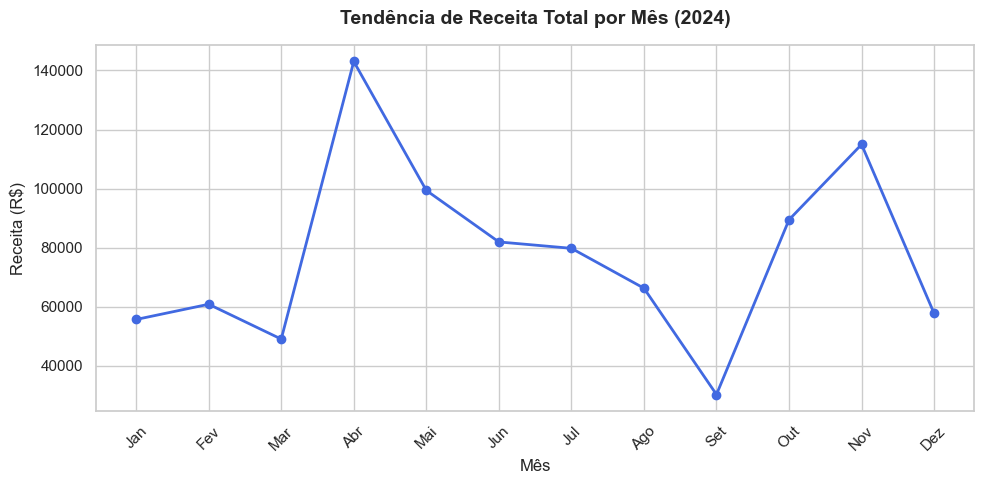

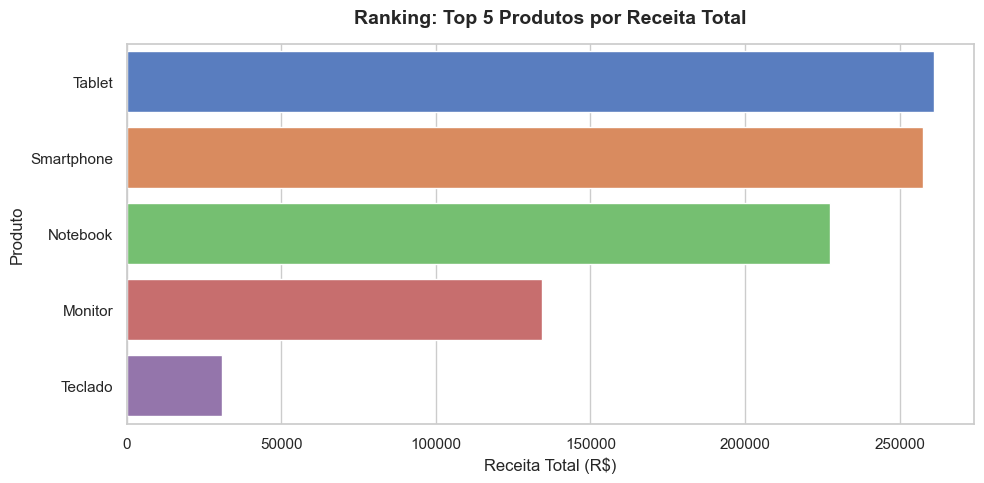

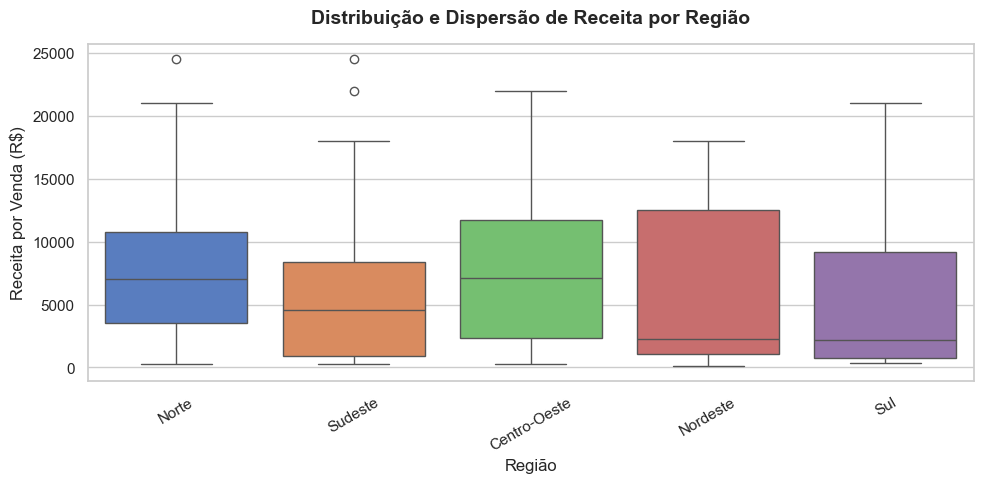

Gráficos salvos com sucesso em: outputs/graficos


In [10]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG.
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")
    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun", "Jul","Ago","Set","Out","Nov","Dez"]
    
    # Gráfico 1: Linha — Receita por Mês
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2, color="royalblue")
    ax.set_title("Tendência de Receita Total por Mês (2024)", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()
    
    # Gráfico 2: Barras Horizontais — Top 5 Produtos
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax, hue="produto", legend=False)
    ax.set_title("Ranking: Top 5 Produtos por Receita Total", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()
    
    # Gráfico 3: Boxplot — Distribuição de Receita por Região
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, hue="regiao", legend=False)
    ax.set_title("Distribuição e Dispersão de Receita por Região", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show()
    plt.close()
    
    print(f"Gráficos salvos com sucesso em: {output_dir}")

gerar_visualizacoes(df, metricas)

## RF10 – Organizar o Código em Funções Reutilizáveis (Demonstração Adicional)

A estrutura do projeto está toda encapsulada em funções organizadas com parâmetros, retornos explícitos e docstrings explicativos.
Abaixo, criamos a função de Ordem Superior (Bonus) `aplicar_transformacao` que recebe uma função callback e a executa sobre uma coluna do DataFrame, ilustrando a aplicação de uma segunda função lambda no projeto.

In [11]:
def aplicar_transformacao(df, coluna, funcao): 
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.
    """
    df = df.copy() 
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao) 
    return df 

# Exemplo de uso 1: Classificar se uma venda é de 'Alto' ou 'Normal' ticket
df_demo = aplicar_transformacao(df, "receita_total", lambda x: "Alto" if x > 5000 else "Normal")
print("=== EXEMPLO: classificação por ticket ===")
print(df_demo[["receita_total", "receita_total_transformado"]].head())

# Exemplo de uso 2: Arredondar receita em milhares
df_demo2 = aplicar_transformacao(df, "receita_total", lambda x: round(x / 1000, 2))
print("\n=== EXEMPLO: receita em milhares (R$ k) ===")
print(df_demo2[["receita_total", "receita_total_transformado"]].head())

=== EXEMPLO: classificação por ticket ===
   receita_total receita_total_transformado
0          240.0                     Normal
3          840.0                     Normal
4        10800.0                       Alto
6        14000.0                       Alto
7        13200.0                       Alto

=== EXEMPLO: receita em milhares (R$ k) ===
   receita_total  receita_total_transformado
0          240.0                        0.24
3          840.0                        0.84
4        10800.0                       10.80
6        14000.0                       14.00
7        13200.0                       13.20


## RF11 – Ler e Escrever Arquivos (CSV e JSON)

Escrevemos os resultados finais consolidados em formato CSV (`metricas_por_mes.csv` e `segmentacao_clientes.csv`) com encoding apropriado para o Microsoft Excel (`utf-8-sig`).
Escrevemos as estatísticas consolidadas calculadas com NumPy em formato JSON (`estatisticas_gerais.json`) formatado e com acentuação correta.
Para garantir o fluxo de leitura e escrita, o arquivo JSON é recarregado e exibido.

In [12]:
def exportar_resultados(metricas, clientes, stats):
    """
    Exporta os resultados da análise nos formatos CSV e JSON.
    Recarrega o JSON logo em seguida para confirmação.
    """
    os.makedirs("outputs", exist_ok=True)
    
    # Exportação CSV
    metricas["por_mes"].to_csv("outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig")
    print("CSV exportado com sucesso: outputs/metricas_por_mes.csv")
    
    clientes.to_csv("outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig")
    print("CSV exportado com sucesso: outputs/segmentacao_clientes.csv")
    
    # Exportação JSON
    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = "outputs/estatisticas_gerais.json"
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"JSON exportado com sucesso: {caminho_json}")
    
    # Leitura de volta para confirmação
    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("\n=== JSON LIDO DE VOLTA PARA CONFIRMAÇÃO ===")
    print(json.dumps(lido, indent=2, ensure_ascii=False))

exportar_resultados(metricas, clientes, stats)

CSV exportado com sucesso: outputs/metricas_por_mes.csv
CSV exportado com sucesso: outputs/segmentacao_clientes.csv
JSON exportado com sucesso: outputs/estatisticas_gerais.json

=== JSON LIDO DE VOLTA PARA CONFIRMAÇÃO ===
{
  "media": 6928.73,
  "mediana": 5100.0,
  "desvio_padrao": 6449.66,
  "total": 928450.0,
  "p25": 1200.0,
  "p75": 10800.0,
  "acima_da_media": 60.0
}


## RF12 – Consolidar a Análise e Salvar o Dataset Final

Consolidamos o pipeline salvando a base sem outliers e com as colunas derivadas finais no diretório `data/final/vendas_final.csv`. 
Essa base será utilizada futuramente para os modelos de IA e análises avançadas.

In [13]:
# Consolidação final do dataset
os.makedirs("data/final", exist_ok=True)
df.to_csv("data/final/vendas_final.csv", index=False)
print("Dataset final salvo com sucesso em: data/final/vendas_final.csv")

# Validação da existência de todos os arquivos esperados
arquivos_esperados = [
    "data/raw/vendas.csv",
    "data/processed/v1_com_outliers/vendas_v1.csv",
    "data/processed/v2_outliers_tratado/vendas_v2.csv",
    "data/final/vendas_final.csv",
    "outputs/metricas_por_mes.csv",
    "outputs/segmentacao_clientes.csv",
    "outputs/estatisticas_gerais.json",
    "outputs/graficos/receita_por_mes.png",
    "outputs/graficos/top_produtos.png",
    "outputs/graficos/dist_regiao.png"
]

print("\n=== VALIDAÇÃO DE ARQUIVOS GERADOS ===")
for arq in arquivos_esperados:
    if os.path.exists(arq):
        print(f"✓ [OK] {arq} - {os.path.getsize(arq)} bytes")
    else:
        print(f"✗ [ERRO] {arq} não foi encontrado!")

Dataset final salvo com sucesso em: data/final/vendas_final.csv

=== VALIDAÇÃO DE ARQUIVOS GERADOS ===
✓ [OK] data/raw/vendas.csv - 9954 bytes
✓ [OK] data/processed/v1_com_outliers/vendas_v1.csv - 9022 bytes
✓ [OK] data/processed/v2_outliers_tratado/vendas_v2.csv - 8624 bytes
✓ [OK] data/final/vendas_final.csv - 12591 bytes
✓ [OK] outputs/metricas_por_mes.csv - 248 bytes
✓ [OK] outputs/segmentacao_clientes.csv - 791 bytes
✓ [OK] outputs/estatisticas_gerais.json - 161 bytes
✓ [OK] outputs/graficos/receita_por_mes.png - 61140 bytes
✓ [OK] outputs/graficos/top_produtos.png - 26932 bytes
✓ [OK] outputs/graficos/dist_regiao.png - 38919 bytes
